# Malmö Property Market — Insights Exploration

Goal: understand the true patterns in the data before building frontend charts.

**Hypotheses to test:**
1. Västra Hamnen is the most expensive neighbourhood by a clear margin
2. Each additional room adds roughly a fixed amount to price (linear)
3. Higher fee suppresses sale price, but the effect is smaller for large apartments
4. Properties built in 1960–1980 (miljonprogrammet) are systematically cheaper per m²
5. The market trended upward until 2022, then plateaued or fell
6. Model residuals are roughly symmetric (not systematically biased by neighbourhood)

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 5)})

def fmt_kr(x, _=None):
    """Format axis tick as Swedish kr, abbreviated."""
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    return f'{x/1_000:.0f}k'

# ── Database connection ────────────────────────────────────────────────────────
DB = '../data/database/properties.duckdb'
con = duckdb.connect(DB, read_only=True)
print('Connected. Tables:', [r[0] for r in con.execute('SHOW TABLES').fetchall()])

Connected. Tables: ['active_listings', 'active_predictions', 'description_archive', 'predictions', 'properties']


In [2]:
# ── Load core dataset ──────────────────────────────────────────────────────────
# Join properties with predictions for residual analysis
df = con.execute("""
    SELECT
        p.property_id,
        p.neighborhood,
        p.final_price,
        p.asking_price,
        p.living_area,
        p.rooms,
        p.association_fee,
        p.building_year,
        p.latitude,
        p.longitude,
        p.sold_date::DATE AS sold_date,
        p.days_on_market,
        p.housing_type,
        p.ownership_type,
        pr.predicted_price,
        pr.price_diff_pct
    FROM properties p
    LEFT JOIN predictions pr ON p.property_id = pr.property_id
    WHERE p.final_price > 0
      AND p.living_area > 0
""").df()

df['price_per_sqm'] = df['final_price'] / df['living_area']
df['year'] = pd.to_datetime(df['sold_date']).dt.year
df['month_str'] = pd.to_datetime(df['sold_date']).dt.to_period('M').astype(str)

print(f'Loaded {len(df):,} properties | {df["neighborhood"].nunique()} neighbourhoods')
print(f'Price range: {df.final_price.min():,.0f} – {df.final_price.max():,.0f} kr')
df.head(3)

Loaded 22,891 properties | 887 neighbourhoods
Price range: 200,000 – 19,400,000 kr


,property_id,neighborhood,final_price,asking_price,living_area,rooms,association_fee,building_year,latitude,longitude,sold_date,days_on_market,housing_type,ownership_type,predicted_price,price_diff_pct,price_per_sqm,year,month_str
0,1001478,Nobeltorget,1150000,895000,56.0,2.0,4211,1947,55.590631,13.023070,2019-05-06,<NA>,Lägenhet,Bostadsrätt,1059000,8.6,20535.714286,2019,2019-05
1,1002586,Lönngården,825000,850000,49.0,2.5,2871,1938,55.582534,13.024223,2019-05-08,<NA>,Lägenhet,Bostadsrätt,873000,-5.5,16836.734694,2019,2019-05
2,1003634,Nobel / Sorgenfri,1425000,1295000,54.0,2.0,2605,<NA>,55.591102,13.026633,2019-05-10,<NA>,Lägenhet,Bostadsrätt,1158000,23.1,26388.888889,2019,2019-05


## 1. Price Distribution

Understand the overall shape: skew, typical range, outliers.

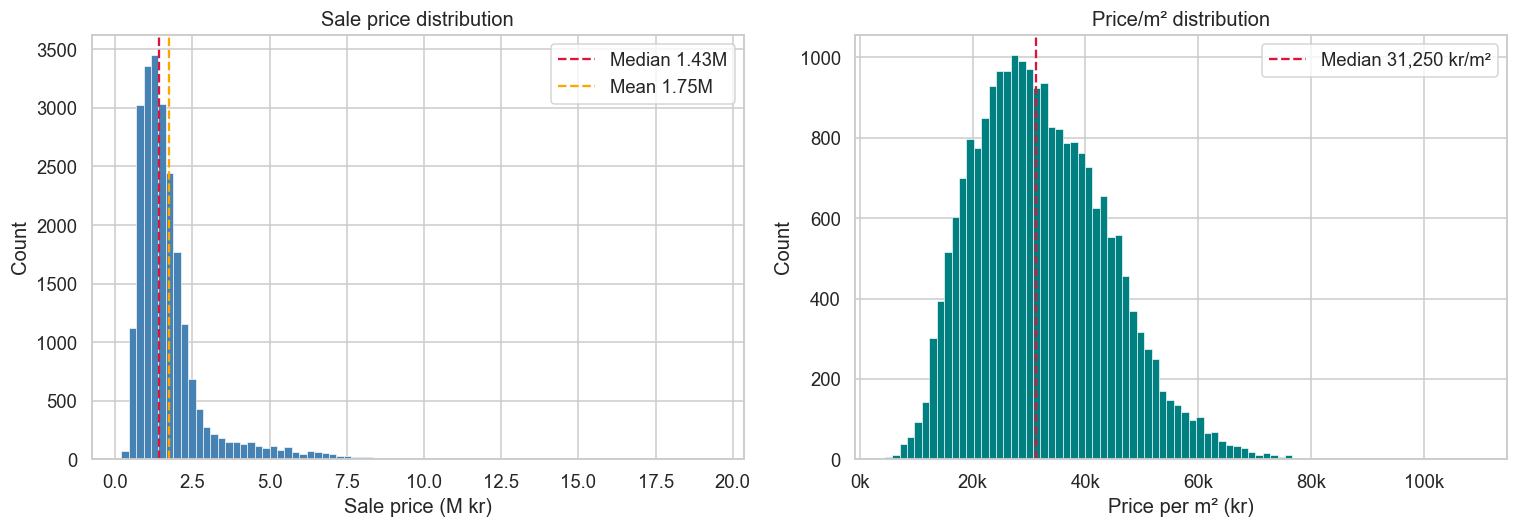

count        22,891
mean      1,752,604
std       1,286,928
min         200,000
25%       1,020,000
50%       1,425,000
75%       1,950,000
max      19,400,000
Name: final_price, dtype: object

Skewness: 3.22  (positive = right-skewed, high outliers)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Final price histogram
ax = axes[0]
ax.hist(df['final_price'] / 1e6, bins=80, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(df['final_price'].median() / 1e6, color='crimson', linestyle='--', label=f'Median {df.final_price.median()/1e6:.2f}M')
ax.axvline(df['final_price'].mean() / 1e6, color='orange', linestyle='--', label=f'Mean {df.final_price.mean()/1e6:.2f}M')
ax.set_xlabel('Sale price (M kr)')
ax.set_ylabel('Count')
ax.set_title('Sale price distribution')
ax.legend()

# Price per sqm histogram
ax2 = axes[1]
p_sqm = df['price_per_sqm'].dropna()
ax2.hist(p_sqm, bins=80, color='teal', edgecolor='white', linewidth=0.4)
ax2.axvline(p_sqm.median(), color='crimson', linestyle='--', label=f'Median {p_sqm.median():,.0f} kr/m²')
ax2.set_xlabel('Price per m² (kr)')
ax2.set_ylabel('Count')
ax2.set_title('Price/m² distribution')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax2.legend()

plt.tight_layout()
plt.show()

print(df['final_price'].describe().apply(lambda x: f'{x:,.0f}'))
print(f'\nSkewness: {df.final_price.skew():.2f}  (positive = right-skewed, high outliers)')

## 2. Neighbourhood Analysis

**Hypotheses tested:**
- H1: Västra Hamnen is the most expensive by a clear margin

Also: which neighbourhoods have enough data to be reliable (≥30 sales)?

In [4]:
# Neighbourhood stats — min 30 sales for reliability
hood = (
    df.dropna(subset=['neighborhood'])
    .groupby('neighborhood')
    .agg(
        median_price=('final_price', 'median'),
        median_sqm=('price_per_sqm', 'median'),
        median_dom=('days_on_market', 'median'),
        count=('final_price', 'count'),
    )
    .query('count >= 30')
    .sort_values('median_sqm', ascending=False)
    .reset_index()
)
print(f'{len(hood)} neighbourhoods with ≥30 sales')
print(f'\nTop 5 by median price/m²:')
print(hood[['neighborhood','median_sqm','median_price','count','median_dom']].head())
print(f'\nBottom 5 by median price/m²:')
print(hood[['neighborhood','median_sqm','median_price','count','median_dom']].tail())

83 neighbourhoods with ≥30 sales

Top 5 by median price/m²:
             neighborhood    median_sqm  median_price  count  median_dom
0              Malmö Live  55940.594059     2850000.0     37        <NA>
1  Davidshall/Malmö Opera  54310.344828     2995000.0     35        <NA>
2             Varvsstaden  54285.714286     2225000.0     99        <NA>
3              Davidshall  52090.825841     2862500.0    256        <NA>
4            Gamla Väster  50000.000000     2995000.0    220        <NA>

Bottom 5 by median price/m²:
       neighborhood    median_sqm  median_price  count  median_dom
78  Södra Sofielund  16216.216216      730000.0     53        <NA>
79         Högaholm  15729.166667      700000.0    103        <NA>
80           Almhög  15045.871560      790000.0    155        <NA>
81           Almvik  14583.333333      700000.0     39        <NA>
82             Oxie  14074.074074     1350000.0    135        <NA>


/var/folders/xp/90b2vmmj0cg7rv097x887f6m0000gn/T/ipykernel_84946/1623195747.py:28: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


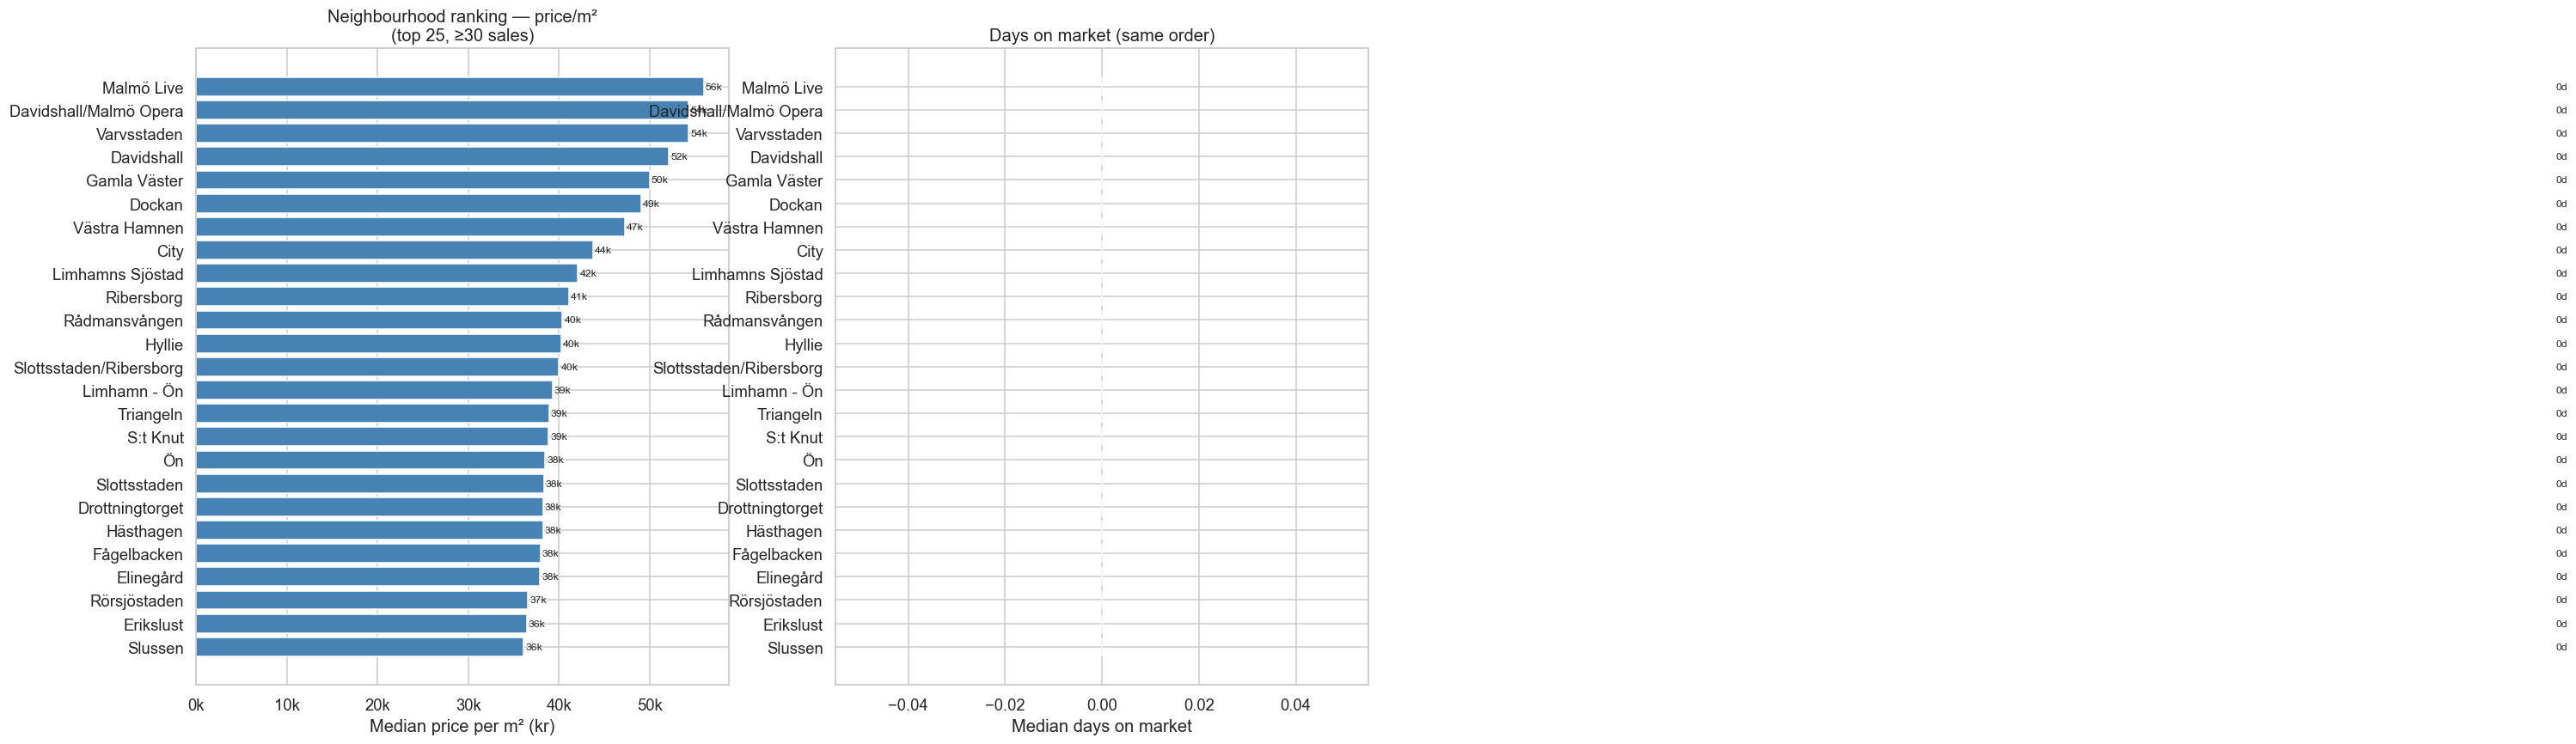

In [5]:
# Horizontal bar chart — neighbourhood ranking by price/m²
top_n = hood.head(25)

fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(top_n)*0.35)))

# Price per sqm
ax = axes[0]
bars = ax.barh(top_n['neighborhood'], top_n['median_sqm'], color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Median price per m² (kr)')
ax.set_title('Neighbourhood ranking — price/m²\n(top 25, ≥30 sales)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
for bar, val in zip(bars, top_n['median_sqm']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val/1000:.0f}k', va='center', fontsize=8)

# Days on market (same neighbourhood order)
ax2 = axes[1]
dom = top_n['median_dom'].fillna(0)
bars2 = ax2.barh(top_n['neighborhood'], dom, color='coral')
ax2.invert_yaxis()
ax2.set_xlabel('Median days on market')
ax2.set_title('Days on market (same order)')
for bar, val in zip(bars2, dom):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}d', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [6]:
# Hypothesis 1 verdict
rank_vh = hood['neighborhood'].tolist().index('Västra Hamnen') + 1 if 'Västra Hamnen' in hood['neighborhood'].values else None
vh_sqm = hood.loc[hood.neighborhood == 'Västra Hamnen', 'median_sqm'].values
print(f"Västra Hamnen rank: #{rank_vh} of {len(hood)} neighbourhoods")
if len(vh_sqm):
    print(f"Västra Hamnen median kr/m²: {vh_sqm[0]:,.0f}")
    print(f"#2 neighbourhood median kr/m²: {hood.iloc[1]['median_sqm']:,.0f}")
    gap = vh_sqm[0] / hood.iloc[1]['median_sqm'] - 1
    print(f"Premium over #2: {gap:.1%}")

bottom5 = hood.tail(5)[['neighborhood','median_sqm','count']]
print(f'\nMost affordable neighbourhoods (≥30 sales):')
print(bottom5.to_string(index=False))

Västra Hamnen rank: #7 of 83 neighbourhoods
Västra Hamnen median kr/m²: 47,235
#2 neighbourhood median kr/m²: 54,310
Premium over #2: -13.0%

Most affordable neighbourhoods (≥30 sales):
   neighborhood   median_sqm  count
Södra Sofielund 16216.216216     53
       Högaholm 15729.166667    103
         Almhög 15045.871560    155
         Almvik 14583.333333     39
           Oxie 14074.074074    135


## 3. Rooms Analysis

**Hypothesis:** each additional room adds roughly a fixed amount (linear relationship)

   rooms  median_price    median_sqm  median_area  count
0      1     1095000.0  31676.873772         36.7   7626
1      2     1500000.0  30555.555556         51.5  12519
2      3     3550000.0  34055.118110        112.0    445
3      4     4100000.0  34130.434783        118.0   1281
4      5     3875000.0  30578.512397        126.0    833
5      6     4905000.0  33460.456808        149.0    156
6      7     5350000.0  31155.227454        156.0     20


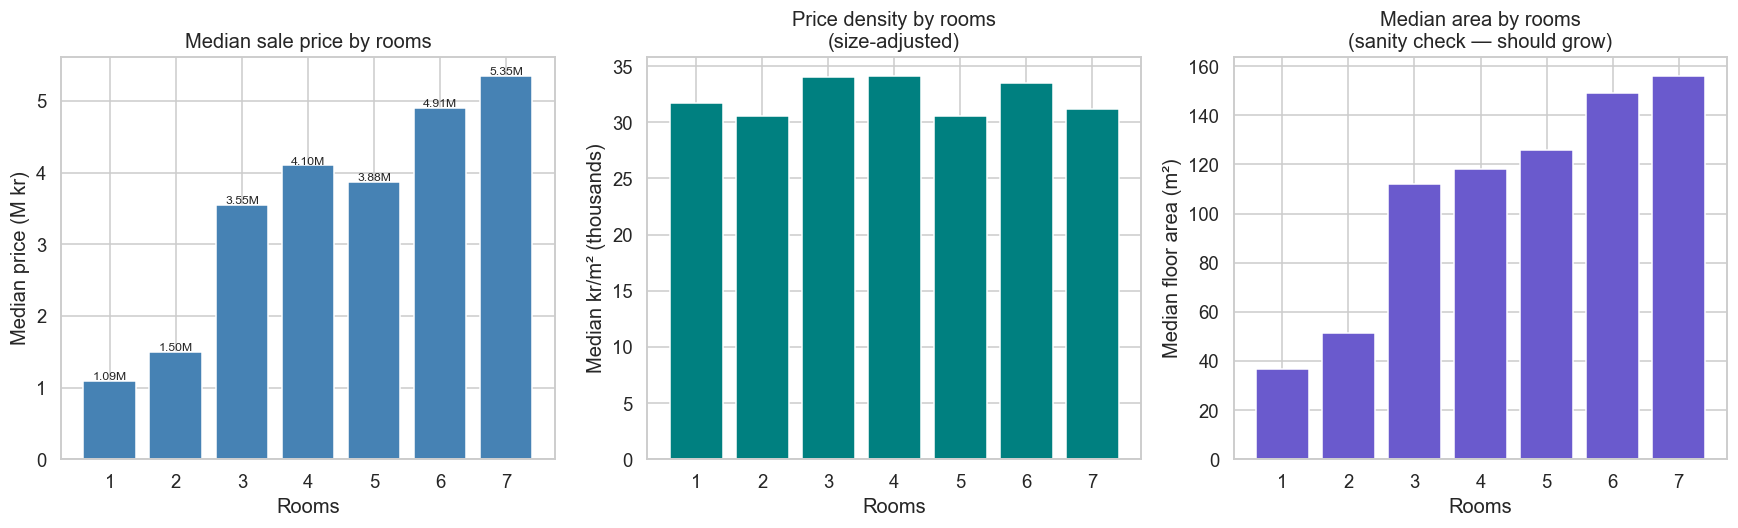


Marginal increase per extra room (median price):
  1→2 rooms: +405,000 kr
  2→3 rooms: +2,050,000 kr
  3→4 rooms: +550,000 kr
  4→5 rooms: +-225,000 kr
  5→6 rooms: +1,030,000 kr
  6→7 rooms: +445,000 kr


In [7]:
rooms_df = (
    df.dropna(subset=['rooms'])
    [lambda d: d['rooms'].between(1, 7)]
    .assign(rooms_int=lambda d: d['rooms'].astype(int))
    .groupby('rooms_int')
    .agg(
        median_price=('final_price', 'median'),
        median_sqm=('price_per_sqm', 'median'),
        median_area=('living_area', 'median'),
        count=('final_price', 'count'),
    )
    .reset_index()
    .rename(columns={'rooms_int': 'rooms'})
)
print(rooms_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Median sale price by rooms
ax = axes[0]
ax.bar(rooms_df['rooms'], rooms_df['median_price']/1e6, color='steelblue')
ax.set_xlabel('Rooms')
ax.set_ylabel('Median price (M kr)')
ax.set_title('Median sale price by rooms')
for _, row in rooms_df.iterrows():
    ax.text(row['rooms'], row['median_price']/1e6 + 0.02, f'{row["median_price"]/1e6:.2f}M',
            ha='center', fontsize=8)

# Median price per sqm — does it change with rooms?
ax2 = axes[1]
ax2.bar(rooms_df['rooms'], rooms_df['median_sqm']/1000, color='teal')
ax2.set_xlabel('Rooms')
ax2.set_ylabel('Median kr/m² (thousands)')
ax2.set_title('Price density by rooms\n(size-adjusted)')

# Median area by rooms (sanity check)
ax3 = axes[2]
ax3.bar(rooms_df['rooms'], rooms_df['median_area'], color='slateblue')
ax3.set_xlabel('Rooms')
ax3.set_ylabel('Median floor area (m²)')
ax3.set_title('Median area by rooms\n(sanity check — should grow)')

plt.tight_layout()
plt.show()

# Marginal kr per additional room
diffs = rooms_df['median_price'].diff().dropna()
print('\nMarginal increase per extra room (median price):')
for r, d in zip(rooms_df['rooms'].iloc[1:], diffs):
    print(f'  {r-1}→{r} rooms: +{d:,.0f} kr')

/var/folders/xp/90b2vmmj0cg7rv097x887f6m0000gn/T/ipykernel_84946/4061248551.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_rooms, labels=range(1, 8), patch_artist=True,


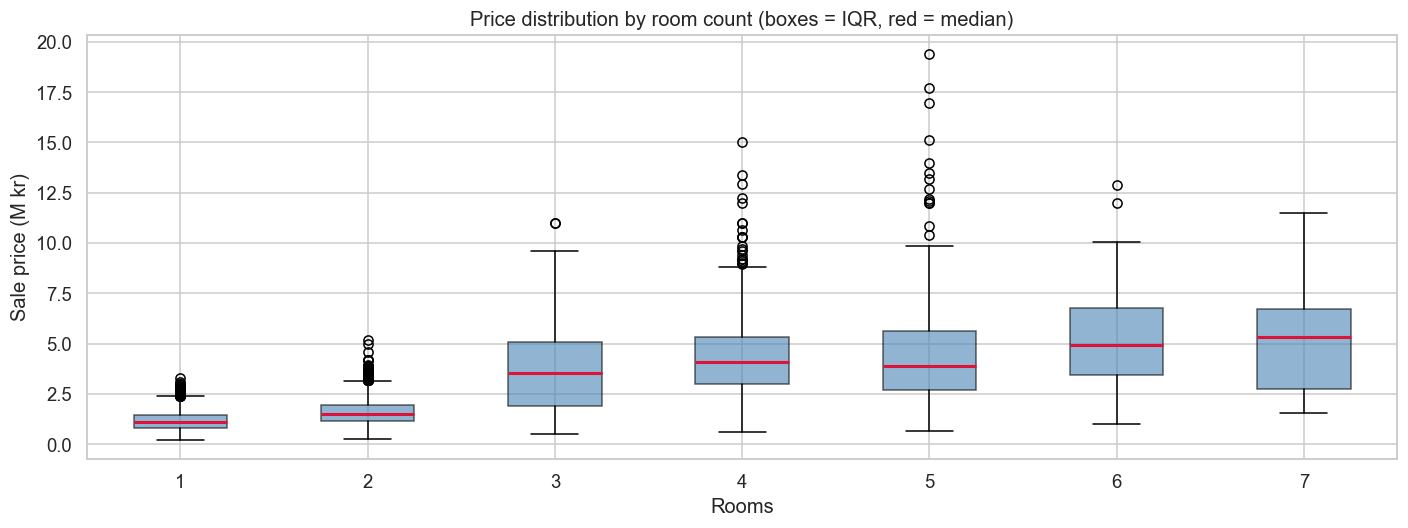

Linear regression: price = -59,918 + 907,055 × rooms
R² = 0.496, p = 0.00e+00


In [8]:
# Boxplot — distribution within each room count
fig, ax = plt.subplots(figsize=(13, 5))
rooms_clean = df.dropna(subset=['rooms'])
rooms_clean = rooms_clean[rooms_clean['rooms'].between(1, 7)].copy()
rooms_clean['rooms_int'] = rooms_clean['rooms'].astype(int)
data_by_rooms = [rooms_clean.loc[rooms_clean['rooms_int'] == r, 'final_price'] / 1e6
                 for r in range(1, 8)]
bp = ax.boxplot(data_by_rooms, labels=range(1, 8), patch_artist=True,
                medianprops={'color': 'crimson', 'linewidth': 2})
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
ax.set_xlabel('Rooms')
ax.set_ylabel('Sale price (M kr)')
ax.set_title('Price distribution by room count (boxes = IQR, red = median)')
plt.tight_layout()
plt.show()

# Linear correlation test
r_mask = df['rooms'].between(1, 7) & df['final_price'].notna()
slope, intercept, r_val, p_val, _ = stats.linregress(df.loc[r_mask, 'rooms'], df.loc[r_mask, 'final_price'])
print(f'Linear regression: price = {intercept:,.0f} + {slope:,.0f} × rooms')
print(f'R² = {r_val**2:.3f}, p = {p_val:.2e}')

## 4. Building Year Analysis

**Hypothesis:** 1960–80 miljonprogrammet era is cheapest per m²; pre-war stock is pricier.

 decade   median_sqm  median_price  count
   1890 42975.206612     3550000.0    253
   1900 38211.382114     2301000.0    639
   1910 39639.639640     2400000.0    229
   1920 38262.910798     1850000.0   1055
   1930 30098.076923     1300000.0   5308
   1940 28585.517047     1295000.0   4370
   1950 28009.433962     1210000.0   2852
   1960 21176.470588      950000.0   1264
   1970 22988.505747      995000.0    681
   1980 18200.000000     1850000.0    207
   1990 25609.756098     1820000.0    211
   2000 39464.285714     2495000.0    721
   2010 42712.495932     1997500.0   1920
   2020 45555.555556     2075000.0    951


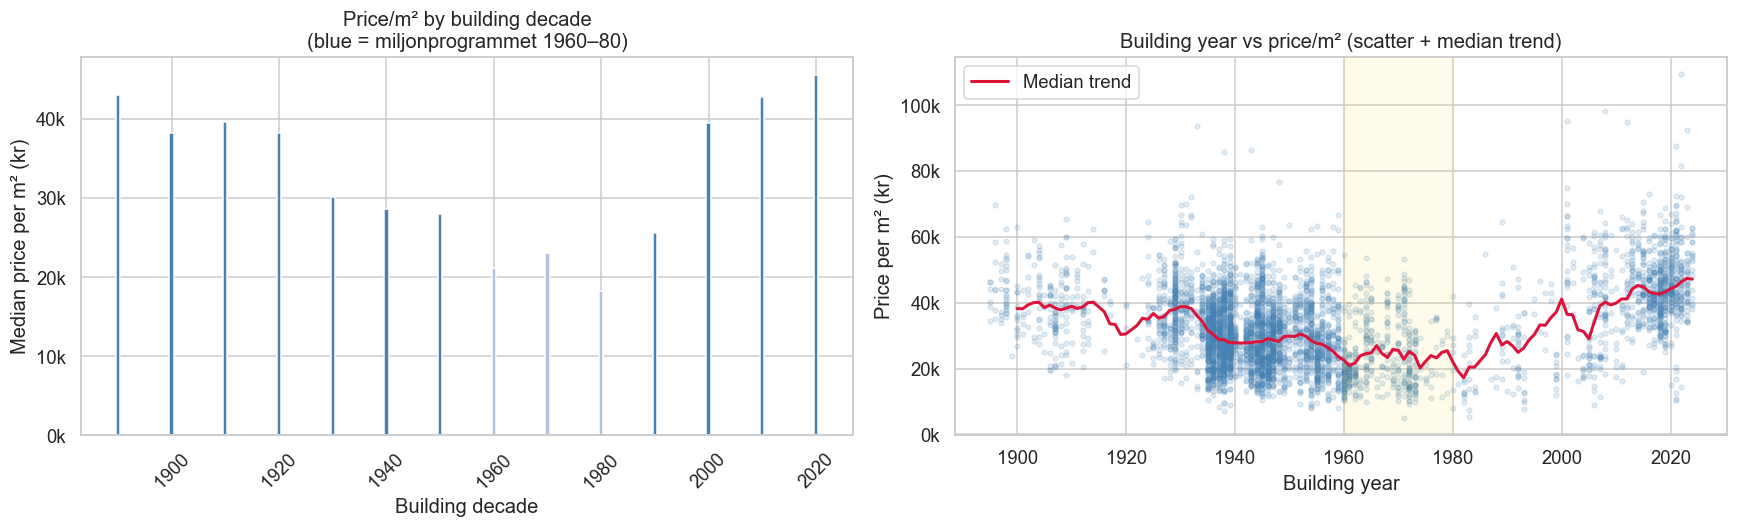

In [9]:
year_df = df.dropna(subset=['building_year']).copy()
year_df = year_df[year_df['building_year'].between(1890, 2025)]
year_df['decade'] = (year_df['building_year'] // 10) * 10

decade_stats = (
    year_df.groupby('decade')
    .agg(
        median_sqm=('price_per_sqm', 'median'),
        median_price=('final_price', 'median'),
        count=('final_price', 'count'),
    )
    .query('count >= 10')
    .reset_index()
)
print(decade_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bars = ax.bar(decade_stats['decade'], decade_stats['median_sqm'],
              color=['#b0c4de' if 1960 <= d <= 1980 else 'steelblue' for d in decade_stats['decade']])
ax.set_xlabel('Building decade')
ax.set_ylabel('Median price per m² (kr)')
ax.set_title('Price/m² by building decade\n(blue = miljonprogrammet 1960–80)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.tick_params(axis='x', rotation=45)

# Scatter of building_year vs price/sqm with LOWESS trend
ax2 = axes[1]
sample = year_df.sample(min(5000, len(year_df)), random_state=42)
ax2.scatter(sample['building_year'], sample['price_per_sqm'], alpha=0.15, s=10, color='steelblue')
# Lowess smooth
from scipy.ndimage import uniform_filter1d
by_yr = year_df.groupby('building_year')['price_per_sqm'].median().reset_index()
by_yr = by_yr[by_yr['building_year'].between(1900, 2024)]
ax2.plot(by_yr['building_year'], uniform_filter1d(by_yr['price_per_sqm'], size=5),
         color='crimson', linewidth=2, label='Median trend')
ax2.set_xlabel('Building year')
ax2.set_ylabel('Price per m² (kr)')
ax2.set_title('Building year vs price/m² (scatter + median trend)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax2.legend()
ax2.axvspan(1960, 1980, alpha=0.08, color='gold', label='miljonprogrammet')

plt.tight_layout()
plt.show()

## 5. Monthly Fee × Area Interaction

**Hypothesis:** Higher fee suppresses price. But does this effect differ for large vs small apartments?

This is the key interaction effect the user asked about.

In [10]:
fee_df = df[(df['association_fee'] > 0) & df['final_price'].notna() & df['living_area'].notna()].copy()
fee_df['area_group'] = pd.cut(
    fee_df['living_area'],
    bins=[0, 59.9, 79.9, 999],
    labels=['Small (<60m²)', 'Medium (60–80m²)', 'Large (>80m²)']
)
# Filter to avoid extreme outliers in fee
fee_df = fee_df[fee_df['association_fee'] <= 8000]

print('Size group counts:')
print(fee_df['area_group'].value_counts())

# Correlation of fee vs price within each group
for grp in ['Small (<60m²)', 'Medium (60–80m²)', 'Large (>80m²)']:
    sub = fee_df[fee_df['area_group'] == grp].dropna(subset=['association_fee', 'final_price'])
    if len(sub) < 5:
        print(f'{grp}: not enough data (n={len(sub)})')
        continue
    r, p = stats.pearsonr(sub['association_fee'], sub['final_price'])
    print(f'{grp}: r = {r:.3f}, p = {p:.3e}, n = {len(sub)}')

Size group counts:
area_group
Small (<60m²)       20268
Large (>80m²)        2304
Medium (60–80m²)        0
Name: count, dtype: int64
Small (<60m²): r = 0.218, p = 1.026e-216, n = 20268
Medium (60–80m²): not enough data (n=0)
Large (>80m²): r = 0.006, p = 7.593e-01, n = 2304


/var/folders/xp/90b2vmmj0cg7rv097x887f6m0000gn/T/ipykernel_84946/1840620784.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sl, ic, _, _, _ = stats.linregress(sub['association_fee'], sub['final_price'])


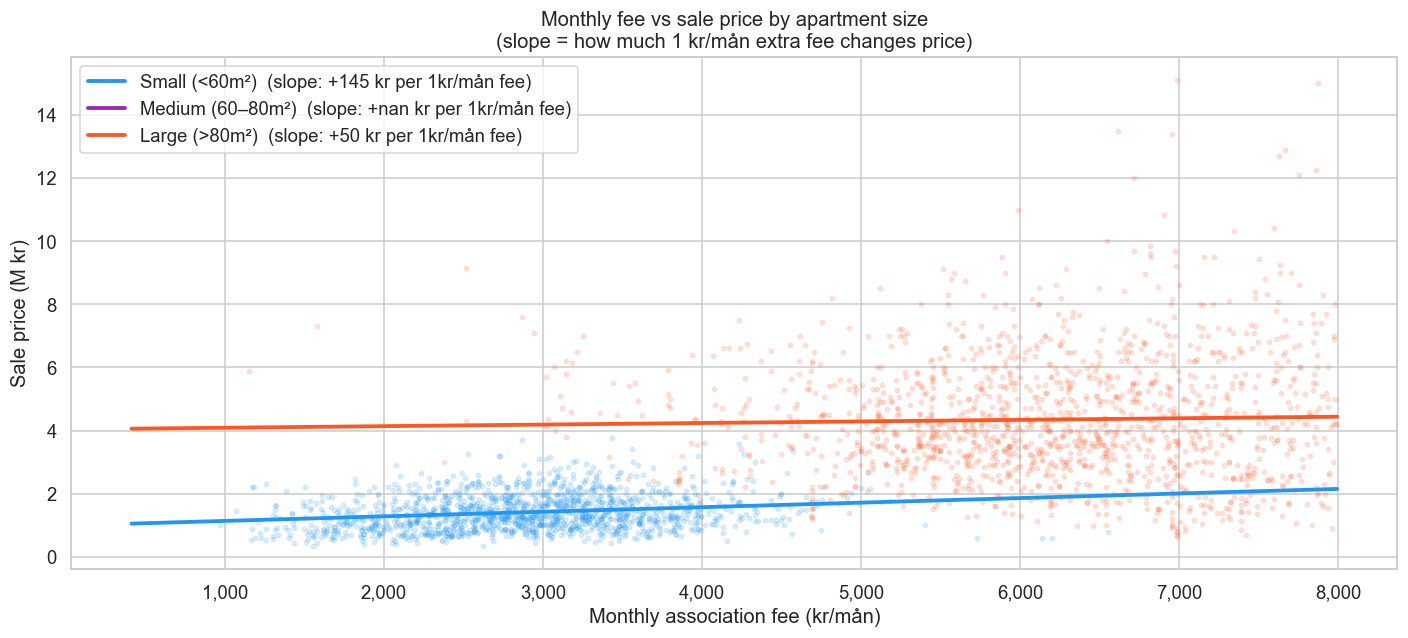


Interpretation: slope tells us — for each extra 1 kr/mån in association fee,
how much does the final price change? If the slope for large flats is smaller
(less negative), the fee matters less for big apartments.


In [11]:
# Scatter + regression lines by area group (small vs large only)
palette = {'Small (<60m²)': '#2196F3', 'Medium (60–80m²)': '#9C27B0', 'Large (>80m²)': '#FF5722'}

fig, ax = plt.subplots(figsize=(13, 6))

for grp, color in palette.items():
    sub = fee_df[fee_df['area_group'] == grp].sample(min(1500, sum(fee_df['area_group'] == grp)), random_state=42)
    ax.scatter(sub['association_fee'], sub['final_price']/1e6, alpha=0.15, s=8, color=color)
    # Regression line
    sl, ic, _, _, _ = stats.linregress(sub['association_fee'], sub['final_price'])
    xs = np.array([fee_df['association_fee'].min(), fee_df['association_fee'].max()])
    ax.plot(xs, (ic + sl*xs)/1e6, color=color, linewidth=2.5, label=f'{grp}  (slope: {sl:+.0f} kr per 1kr/mån fee)')

ax.set_xlabel('Monthly association fee (kr/mån)')
ax.set_ylabel('Sale price (M kr)')
ax.set_title('Monthly fee vs sale price by apartment size\n'
             '(slope = how much 1 kr/mån extra fee changes price)')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

print('\nInterpretation: slope tells us — for each extra 1 kr/mån in association fee,')
print('how much does the final price change? If the slope for large flats is smaller')
print('(less negative), the fee matters less for big apartments.')

/var/folders/xp/90b2vmmj0cg7rv097x887f6m0000gn/T/ipykernel_84946/2128733058.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['fee_bucket', 'area_group'])


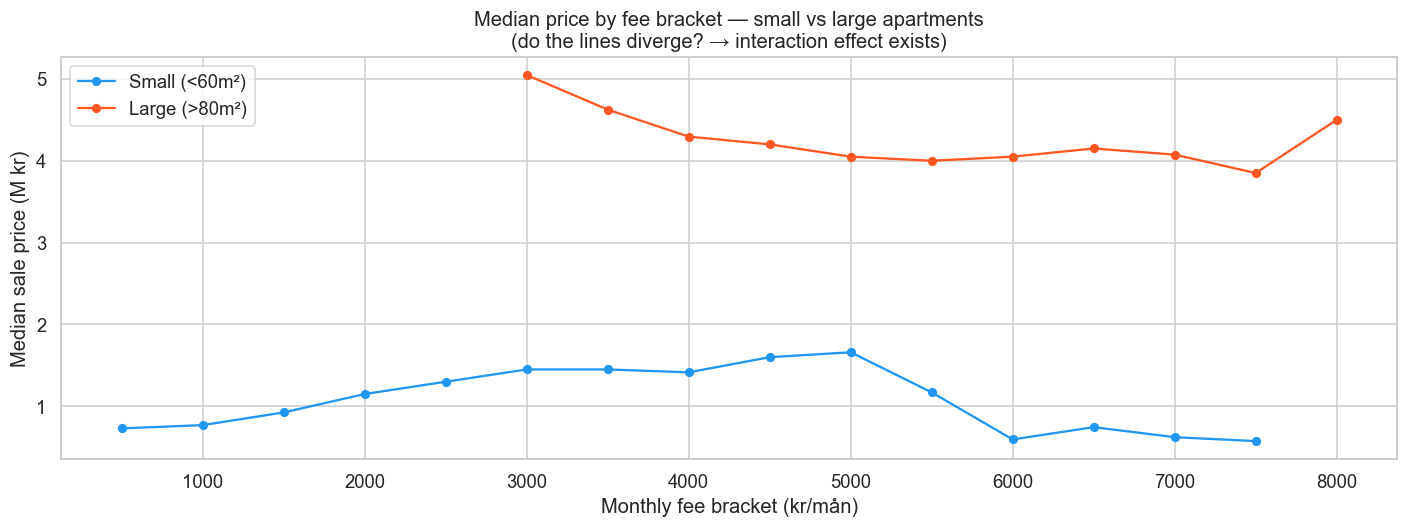

In [12]:
# Bin fee into 500 kr brackets and compute medians per group — cleaner signal
fee_df['fee_bucket'] = (fee_df['association_fee'] / 500).round() * 500

pivot = (
    fee_df[fee_df['area_group'] != 'Medium (60–80m²)']
    .groupby(['fee_bucket', 'area_group'])
    .agg(median_price=('final_price', 'median'), count=('final_price', 'count'))
    .query('count >= 5')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
for grp, color in [('Small (<60m²)', '#2196F3'), ('Large (>80m²)', '#FF5722')]:
    sub = pivot[pivot['area_group'] == grp]
    ax.plot(sub['fee_bucket'], sub['median_price']/1e6, 'o-', color=color, markersize=5, label=grp)

ax.set_xlabel('Monthly fee bracket (kr/mån)')
ax.set_ylabel('Median sale price (M kr)')
ax.set_title('Median price by fee bracket — small vs large apartments\n'
             '(do the lines diverge? → interaction effect exists)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Price Trend Over Time

**Hypothesis:** Market trended upward until ~2022, then plateaued or fell.

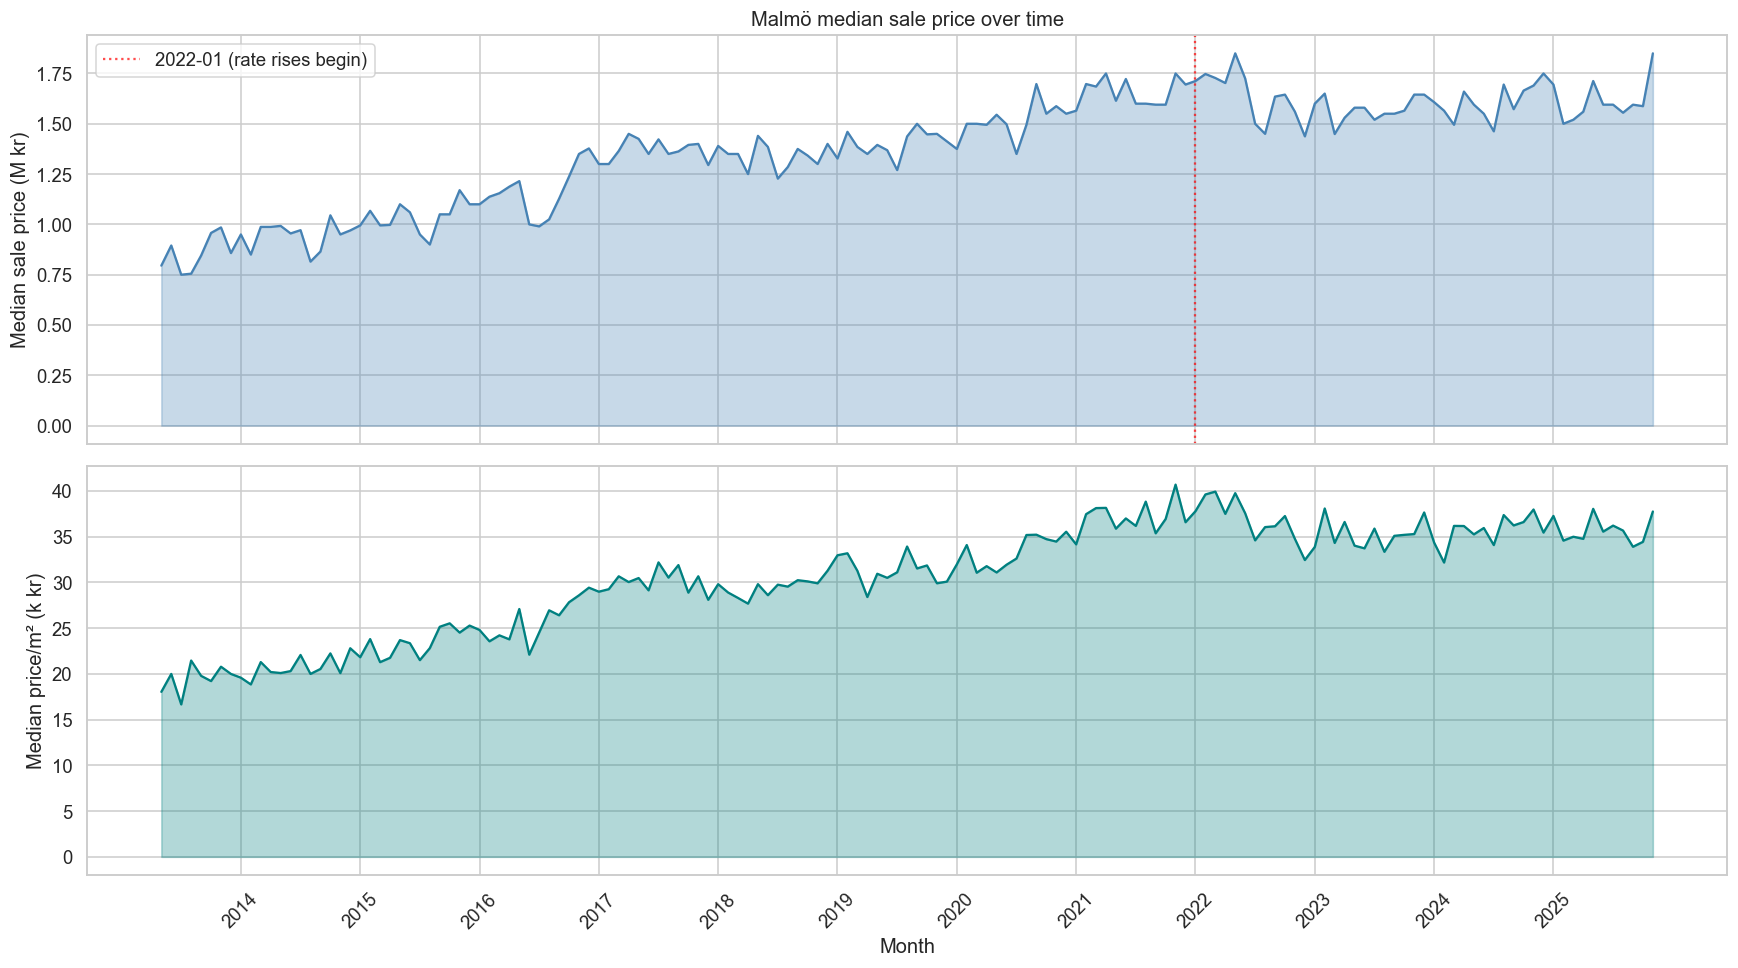

Peak month: 2022-05 → 1.85M kr
Latest month (2025-11): 1.85M kr
Change from peak: +0.0%


In [13]:
trend = (
    df[df['sold_date'].notna()]
    .assign(period=lambda d: d['month_str'])
    .groupby('period')
    .agg(
        median_price=('final_price', 'median'),
        median_sqm=('price_per_sqm', 'median'),
        count=('final_price', 'count'),
    )
    .query('count >= 20')   # avoid months with too few sales
    .reset_index()
    .sort_values('period')
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

ax = axes[0]
ax.fill_between(range(len(trend)), trend['median_price']/1e6, alpha=0.3, color='steelblue')
ax.plot(range(len(trend)), trend['median_price']/1e6, color='steelblue', linewidth=1.5)
# Mark 2022 if present
matches_2022 = trend[trend['period'] >= '2022-01']
if len(matches_2022):
    ax.axvline(matches_2022.index[0], color='red', linestyle=':', alpha=0.7,
               label='2022-01 (rate rises begin)')
ax.set_ylabel('Median sale price (M kr)')
ax.set_title('Malmö median sale price over time')
ax.legend()

ax2 = axes[1]
ax2.fill_between(range(len(trend)), trend['median_sqm']/1000, alpha=0.3, color='teal')
ax2.plot(range(len(trend)), trend['median_sqm']/1000, color='teal', linewidth=1.5)
ax2.set_ylabel('Median price/m² (k kr)')
ax2.set_xlabel('Month')

# X-axis: show yearly labels
yearly_positions = [i for i, p in enumerate(trend['period']) if p.endswith('-01')]
yearly_labels = [p[:4] for p in trend['period'] if p.endswith('-01')]
ax2.set_xticks(yearly_positions)
ax2.set_xticklabels(yearly_labels, rotation=45)

plt.tight_layout()
plt.show()

# Find peak
peak_row = trend.loc[trend['median_price'].idxmax()]
print(f'Peak month: {peak_row["period"]} → {peak_row["median_price"]/1e6:.2f}M kr')
latest = trend.iloc[-1]
print(f'Latest month ({latest["period"]}): {latest["median_price"]/1e6:.2f}M kr')
pct_from_peak = (latest['median_price'] - peak_row['median_price']) / peak_row['median_price'] * 100
print(f'Change from peak: {pct_from_peak:+.1f}%')

In [14]:
# Last 24 months specifically (for the frontend chart)
recent = trend.tail(24).copy()
print(f'Last 24 months: {recent["period"].iloc[0]} to {recent["period"].iloc[-1]}')
print(f'Price change over last 24 months:')
pct_24m = (recent['median_price'].iloc[-1] - recent['median_price'].iloc[0]) / recent['median_price'].iloc[0] * 100
print(f'  {pct_24m:+.1f}%')

Last 24 months: 2023-12 to 2025-11
Price change over last 24 months:
  +12.5%


## 7. Neighbourhood × Rooms Interaction

Do extra rooms add more value in expensive neighbourhoods? Or is the gain flat across all areas?

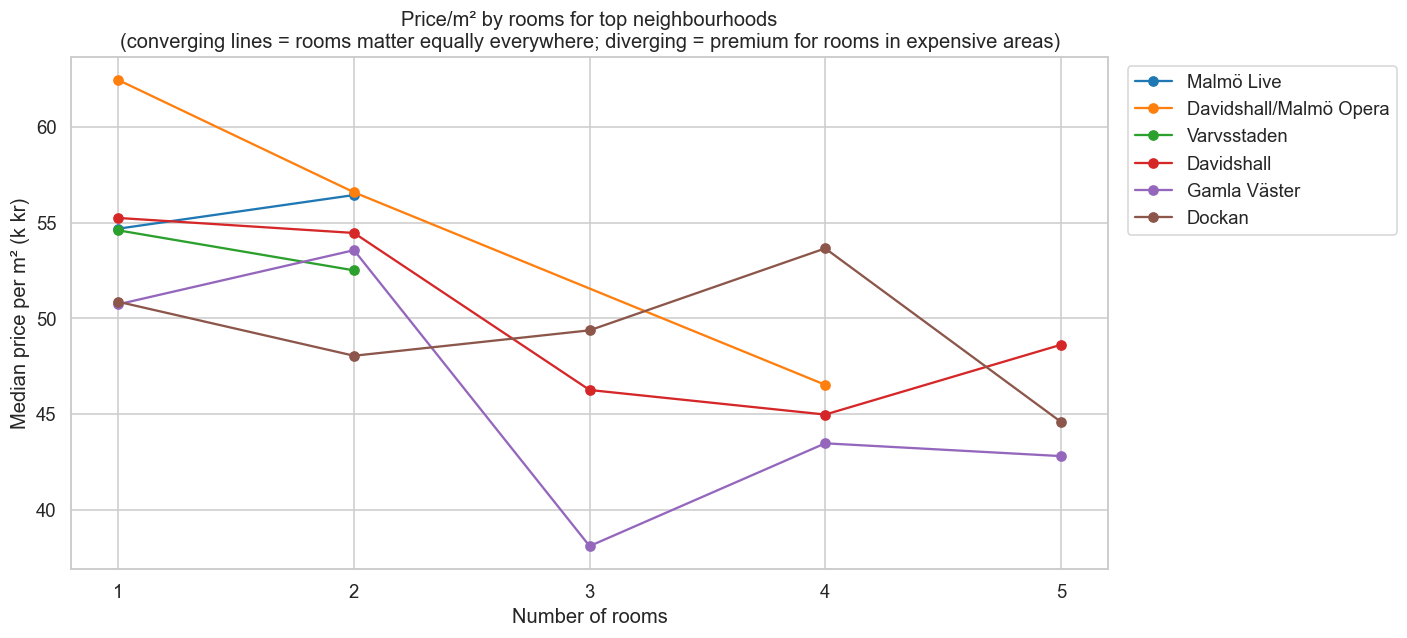

In [15]:
# Top 6 neighbourhoods by count for this analysis
top_hoods = hood.head(6)['neighborhood'].tolist()

interaction_df = (
    df.dropna(subset=['rooms'])
    [lambda d: d['rooms'].between(1, 5) & d['neighborhood'].isin(top_hoods)]
    .assign(rooms_int=lambda d: d['rooms'].astype(int))
    .groupby(['neighborhood', 'rooms_int'])
    .agg(median_sqm=('price_per_sqm', 'median'), count=('final_price', 'count'))
    .query('count >= 5')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))
palette2 = sns.color_palette('tab10', len(top_hoods))

for i, hood_name in enumerate(top_hoods):
    sub = interaction_df[interaction_df['neighborhood'] == hood_name]
    ax.plot(sub['rooms_int'], sub['median_sqm']/1000, 'o-', color=palette2[i],
            label=hood_name, markersize=6)

ax.set_xlabel('Number of rooms')
ax.set_ylabel('Median price per m² (k kr)')
ax.set_title('Price/m² by rooms for top neighbourhoods\n'
             '(converging lines = rooms matter equally everywhere; diverging = premium for rooms in expensive areas)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

## 8. Model Residuals — Systematic Bias?

Does the model over/underestimate in particular neighbourhoods?

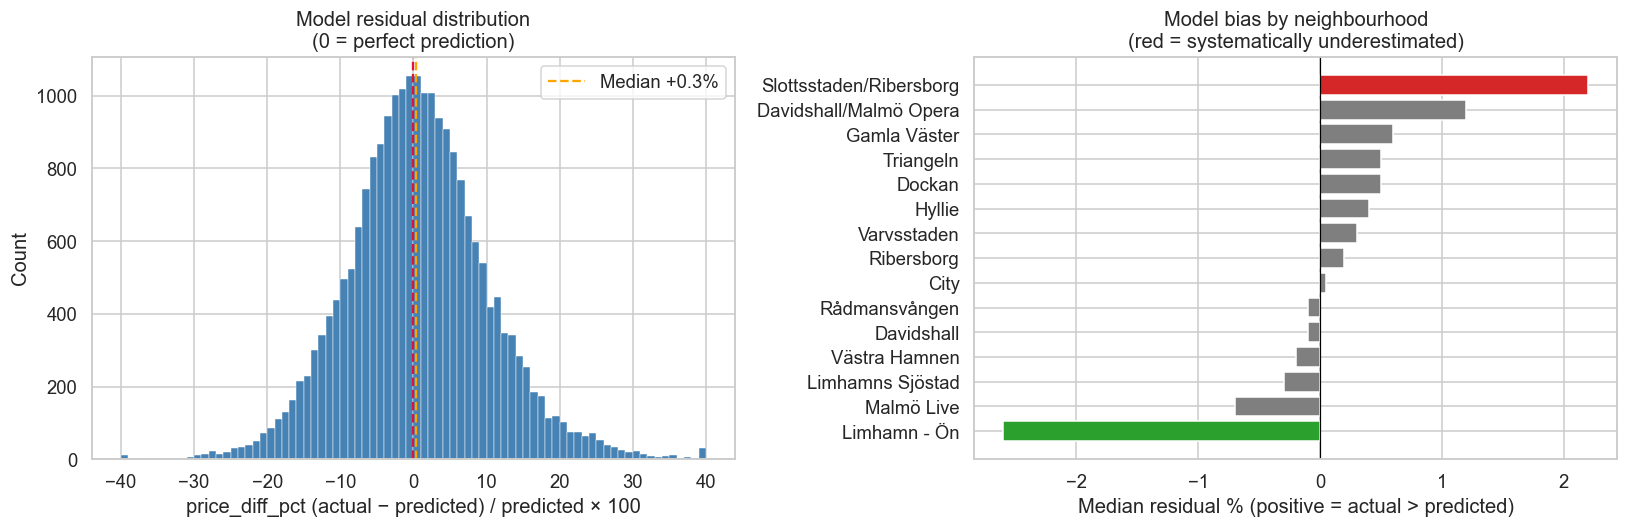

Overall residuals: mean=+0.62%, median=+0.30%
Skewness: 0.28

Worst biased neighbourhoods (|median resid| > 5%):
Empty DataFrame
Columns: [neighborhood, median_resid, count]
Index: []


In [16]:
resid = df.dropna(subset=['price_diff_pct', 'neighborhood'])

# Overall distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.hist(resid['price_diff_pct'].clip(-40, 40), bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='crimson', linestyle='--')
ax.axvline(resid['price_diff_pct'].median(), color='orange', linestyle='--',
           label=f'Median {resid["price_diff_pct"].median():+.1f}%')
ax.set_xlabel('price_diff_pct (actual − predicted) / predicted × 100')
ax.set_ylabel('Count')
ax.set_title('Model residual distribution\n(0 = perfect prediction)')
ax.legend()

# Residuals by top neighbourhood
ax2 = axes[1]
top_hoods_resid = hood.head(15)['neighborhood'].tolist()
resid_by_hood = (
    resid[resid['neighborhood'].isin(top_hoods_resid)]
    .groupby('neighborhood')
    .agg(median_resid=('price_diff_pct', 'median'), count=('price_diff_pct', 'count'))
    .sort_values('median_resid')
    .reset_index()
)
colors = ['#d62728' if v > 2 else '#2ca02c' if v < -2 else '#7f7f7f'
          for v in resid_by_hood['median_resid']]
ax2.barh(resid_by_hood['neighborhood'], resid_by_hood['median_resid'], color=colors)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Median residual % (positive = actual > predicted)')
ax2.set_title('Model bias by neighbourhood\n(red = systematically underestimated)')
plt.tight_layout()
plt.show()

print(f'Overall residuals: mean={resid.price_diff_pct.mean():+.2f}%, median={resid.price_diff_pct.median():+.2f}%')
print(f'Skewness: {resid.price_diff_pct.skew():.2f}')
print('\nWorst biased neighbourhoods (|median resid| > 5%):')
print(resid_by_hood[resid_by_hood['median_resid'].abs() > 5][['neighborhood','median_resid','count']])

## 9. Summary — Hypotheses Verdict

Fill in after running all cells above.

In [17]:
# ── Quick summary stats for the frontend chart design ──────────────────────────

print('=== NEIGHBOURHOOD ===')
print(f'Qualifying neighbourhoods (≥30 sales): {len(hood)}')
print(f'Most expensive: {hood.iloc[0]["neighborhood"]} ({hood.iloc[0]["median_sqm"]:,.0f} kr/m²)')
print(f'Most affordable: {hood.iloc[-1]["neighborhood"]} ({hood.iloc[-1]["median_sqm"]:,.0f} kr/m²)')
print(f'Price ratio (top / bottom): {hood.iloc[0]["median_sqm"] / hood.iloc[-1]["median_sqm"]:.1f}×')

print('\n=== ROOMS ===')
for _, r in rooms_df.iterrows():
    print(f'  {r["rooms"]:.0f} rooms: median {r["median_price"]/1e6:.2f}M kr | {r["count"]} sales')

print('\n=== BUILDING DECADES ===')
print(decade_stats[['decade','median_sqm','count']].to_string(index=False))

print('\n=== FEE × AREA INTERACTION ===')
for grp in ['Small (<60m²)', 'Medium (60–80m²)', 'Large (>80m²)']:
    sub = fee_df[fee_df['area_group'] == grp].dropna(subset=['association_fee', 'final_price'])
    if len(sub) < 5:
        print(f'  {grp}: not enough data')
        continue
    sl, _, _, _, _ = stats.linregress(sub['association_fee'], sub['final_price'])
    print(f'  {grp}: {sl:+.1f} kr price change per 1 kr/mån fee increase')

print('\n=== PRICE TREND ===')
print(f'Peak: {peak_row["period"]} at {peak_row["median_price"]/1e6:.2f}M kr')
print(f'Latest: {latest["period"]} at {latest["median_price"]/1e6:.2f}M kr  ({pct_from_peak:+.1f}% from peak)')

print('\n=== MODEL RESIDUALS ===')
print(f'Mean: {resid.price_diff_pct.mean():+.2f}%  |  Median: {resid.price_diff_pct.median():+.2f}%')

=== NEIGHBOURHOOD ===
Qualifying neighbourhoods (≥30 sales): 83
Most expensive: Malmö Live (55,941 kr/m²)
Most affordable: Oxie (14,074 kr/m²)
Price ratio (top / bottom): 4.0×

=== ROOMS ===
  1 rooms: median 1.09M kr | 7626.0 sales
  2 rooms: median 1.50M kr | 12519.0 sales
  3 rooms: median 3.55M kr | 445.0 sales
  4 rooms: median 4.10M kr | 1281.0 sales
  5 rooms: median 3.88M kr | 833.0 sales
  6 rooms: median 4.91M kr | 156.0 sales
  7 rooms: median 5.35M kr | 20.0 sales

=== BUILDING DECADES ===
 decade   median_sqm  count
   1890 42975.206612    253
   1900 38211.382114    639
   1910 39639.639640    229
   1920 38262.910798   1055
   1930 30098.076923   5308
   1940 28585.517047   4370
   1950 28009.433962   2852
   1960 21176.470588   1264
   1970 22988.505747    681
   1980 18200.000000    207
   1990 25609.756098    211
   2000 39464.285714    721
   2010 42712.495932   1920
   2020 45555.555556    951

=== FEE × AREA INTERACTION ===
  Small (<60m²): +163.3 kr price change p

In [18]:
con.close()
print('Connection closed.')

Connection closed.
